# First-Estimation Results: Visualization

Visualizes parameter-estimation results saved as CSVs in `results/first_estimation/`.
This notebook is pure load-from-CSV + plot -- it does NOT import the estimator, does NOT run ipopt, and does NOT rebuild any model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle as MplRect
from matplotlib.transforms import blended_transform_factory
from pathlib import Path

RESULTS_DIR = Path('results/first_estimation')
FIG_DIR = RESULTS_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

ci_df = pd.read_csv(RESULTS_DIR / 'confidence_intervals.csv', index_col=0)
corr_df = pd.read_csv(RESULTS_DIR / 'correlation.csv', index_col=0)
cov_df = pd.read_csv(RESULTS_DIR / 'covariance.csv', index_col=0)
struct_df = pd.read_csv(RESULTS_DIR / 'structural_report_per_parameter.csv', index_col=0)
ident_df = pd.read_csv(RESULTS_DIR / 'structural_report_identifiability.csv', index_col=0)

# Reduced (identifiable-only) covariance / CIs -- well-conditioned, used by the
# forest plot and the CV box plot below.
ci_ident_df = pd.read_csv(RESULTS_DIR / 'confidence_intervals_identifiable.csv', index_col=0)
cov_ident_df = pd.read_csv(RESULTS_DIR / 'covariance_identifiable.csv', index_col=0)

# Stack per-condition sensitivity CSVs into G_stack of shape (n_cond, 18, 37)
sens_files = sorted((RESULTS_DIR / 'sensitivity').glob('*.csv'))
G_list = []
row_kind = None
row_name = None
param_cols = None
cond_names = []

for fp in sens_files:
    df = pd.read_csv(fp)
    if row_kind is None:
        row_kind = df['kind'].tolist()
        row_name = df['name'].tolist()
        param_cols = [c for c in df.columns if c not in ('kind', 'name')]
    else:
        assert df['kind'].tolist() == row_kind, 'row_kind mismatch across conditions'
        assert df['name'].tolist() == row_name, 'row_name mismatch across conditions'
    G_list.append(df[param_cols].values.astype(float))
    cond_names.append(fp.stem)

G_stack = np.stack(G_list, axis=0)  # shape: (n_cond, 18, 37)
print(f'G_stack shape: {G_stack.shape}, conditions: {len(cond_names)}')

PARAMS = list(ci_df.index)
assert PARAMS == list(corr_df.columns), 'PARAMS order mismatch between ci_df and corr_df'
assert PARAMS == param_cols, 'PARAMS order mismatch between ci_df and sensitivity param columns'
print(f'PARAMS verified ({len(PARAMS)} params)')
print(f'Identifiable params loaded ({len(ci_ident_df)}): {list(ci_ident_df.index)}')

G_stack shape: (22, 18, 37), conditions: 22
PARAMS verified (37 params)
Identifiable params loaded (6): ['v_max_1', 'Ka2_1', 'K_g6p_1', 'kcat_f_2', 'kcat_f_3', 'kcat_f_4']


## Verification: tight CI vs big covariance entry is not a bug

The forest plot shows `v_max_1` with a tight confidence interval while
`covariance.csv` has large entries in the `v_max_1` row. The cell below confirms
these are consistent: each CI standard error equals the square root of the
covariance *diagonal*, and the large numbers live *off* the diagonal (couplings
to non-identifiable parameters whose own variances are enormous). The forest plot
uses only the diagonal, so it is correct -- and below it is rebuilt from the
well-conditioned identifiable-only covariance so the scale is readable.

In [2]:
# VERIFICATION: the CI plot and the covariance matrix are consistent (no bug).
#
# 1. Every CI std_err equals sqrt of the covariance diagonal -- the forest plot
#    uses only that diagonal, so it draws the correct interval.
# 2. The "big entry" in v_max_1's covariance row is OFF-diagonal: it couples
#    v_max_1 to non-identifiable partners whose own variances are astronomical.
#    The marginal CI (diagonal) stays tight while the off-diagonal is huge.
_diag = np.sqrt(np.clip(np.diag(cov_df.to_numpy()), 0.0, None))
assert np.allclose(_diag, ci_df['std_err'].to_numpy(), rtol=1e-6, atol=1e-9), \
    'std_err != sqrt(diag(cov)) -- this WOULD be a bug'
print('OK: ci_df.std_err == sqrt(diag(covariance)) for all 37 params.')

_vd = cov_df.loc['v_max_1', 'v_max_1']
_off = cov_df.loc['v_max_1'].drop('v_max_1').abs()
_pmax = _off.idxmax()
print(f"\nv_max_1 diagonal variance      : {_vd:.3e}  -> std_err {np.sqrt(_vd):.3f}"
      f"  -> CV {ci_df.loc['v_max_1','cv_percent']:.1f}%  (tight, identifiable)")
print(f"v_max_1 largest off-diagonal   : cov[v_max_1, {_pmax}] = {cov_df.loc['v_max_1', _pmax]:.3e}")
print(f"  partner {_pmax} variance      : {cov_df.loc[_pmax, _pmax]:.3e}  (non-identifiable blow-up)")
print("\nConclusion: tight marginal CI + huge off-diagonal entry are both correct;"
      "\nthe forest plot below therefore uses the well-conditioned identifiable-only CIs.")

OK: ci_df.std_err == sqrt(diag(covariance)) for all 37 params.

v_max_1 diagonal variance      : 1.288e+01  -> std_err 3.589  -> CV 4.3%  (tight, identifiable)
v_max_1 largest off-diagonal   : cov[v_max_1, Ks_3pg_7] = 8.494e+04
  partner Ks_3pg_7 variance      : 1.231e+09  (non-identifiable blow-up)

Conclusion: tight marginal CI + huge off-diagonal entry are both correct;
the forest plot below therefore uses the well-conditioned identifiable-only CIs.


In [3]:
# Shared style block -- copied verbatim from sensitivity_analysis.ipynb cells 4c2bbb4e and 3bd5d160

reaction_groups = [
    ('PTS',  0,  4,  '#d73027'), ('PGI',  5,  7,  '#4575b4'),
    ('PFK',  8, 12,  '#1a9850'), ('FBA', 13, 16,  '#762a83'),
    ('TPI', 17, 19,  '#e08214'), ('GAP', 20, 25,  '#8c510a'),
    ('PGK', 26, 30,  '#de77ae'), ('GPM', 31, 33,  '#80cdc1'),
    ('ENO', 34, 36,  '#74add1'),
]

# LaTeX labels in ALL_PARAMS order (37 entries)
_param_labels_orig = [
    r'$v^{\max}_{PTS}$', r'$K_{a1}$', r'$K_{a2}$', r'$K_{a3}$', r'$K_{g6p}$',
    r'$K_{s,g6p}^{2}$', r'$K_{p,f6p}^{2}$', r'$k^{+}_{cat,2}$',
    r'$K_{s,f6p}^{3}$', r'$K_{s,atp}^{3}$', r'$K_{p,fbp}^{3}$', r'$K_{p,adp}^{3}$', r'$k^{+}_{cat,3}$',
    r'$K_{s,fbp}^{4}$', r'$K_{p,g3p}^{4}$', r'$K_{p,dhap}^{4}$', r'$k^{+}_{cat,4}$',
    r'$k^{+}_{cat,5}$', r'$K_{s,dhap}^{5}$', r'$K_{p,g3p}^{5}$',
    r'$k^{+}_{cat,6}$', r'$K_{s,g3p}^{6}$', r'$K_{s,pi}^{6}$', r'$K_{s,nad}^{6}$', r'$K_{p,pgp}^{6}$', r'$K_{p,nadh}^{6}$',
    r'$k^{+}_{cat,7}$', r'$K_{s,pgp}^{7}$', r'$K_{s,adp}^{7}$', r'$K_{p,3pg}^{7}$', r'$K_{p,atp}^{7}$',
    r'$k^{+}_{cat,8}$', r'$K_{s,3pg}^{8}$', r'$K_{p,2pg}^{8}$',
    r'$k^{+}_{cat,9}$', r'$K_{s,2pg}^{9}$', r'$K_{p,pep}^{9}$',
]

# Reorder: within each reaction, kcat first then K_m (PTS unchanged)
_KCAT0 = {7, 12, 16, 17, 20, 26, 31, 34}
_PTS0  = {0, 1, 2, 3, 4}
def _t0(i): return 'pts' if i in _PTS0 else ('kcat' if i in _KCAT0 else 'km')
_rank = {'kcat': 0, 'km': 1, 'pts': 0}
_perm = []
for _nm, _is, _ie, _c in reaction_groups:
    _perm += sorted(range(_is, _ie + 1), key=lambda i: (_rank[_t0(i)], i))

param_labels_p = [_param_labels_orig[i] for i in _perm]
KCAT_IDX = {p for p, o in enumerate(_perm) if o in _KCAT0}
PTS_IDX  = {p for p, o in enumerate(_perm) if o in _PTS0}

TYPE_COLOR = {'kcat': '#117733', 'km': '#332288', 'pts': '#882255'}
def _type_color(i):
    if i in PTS_IDX:  return TYPE_COLOR['pts']
    if i in KCAT_IDX: return TYPE_COLOR['kcat']
    return TYPE_COLOR['km']

def styled_matrix_heatmap(M_permuted, vmin, vmax, cbar_label, savepath,
                          cmap_name='RdBu_r', extend='neither'):
    """
    Render a pre-permuted square matrix with the reference styling from
    sensitivity_analysis.ipynb (cell 4c2bbb4e): type-colored ticks, white cell
    gridlines, heavy block separators, colored on-diagonal frames, top+right
    reaction strips, hidden spines, size-matched colorbar, savefig at dpi=300.
    rcParams are saved and restored around the call.
    """
    _rc_save = {k: mpl.rcParams[k] for k in (
        'font.family', 'font.size', 'axes.linewidth', 'mathtext.fontset')}
    mpl.rcParams.update({
        'font.family':     'sans-serif',
        'font.size':        9,
        'axes.linewidth':   0.6,
        'mathtext.fontset': 'dejavusans',
    })

    cmap = mpl.colormaps[cmap_name].copy()
    cmap.set_bad('#e9e9ec')

    GAP      = 0.35
    STRIP    = 1.4
    TICK_FS  = 11
    STRIP_FS = 9

    n = M_permuted.shape[0]
    fig, ax = plt.subplots(figsize=(10.5, 10.5), dpi=200)
    im = ax.imshow(M_permuted, cmap=cmap, vmin=vmin, vmax=vmax,
                   interpolation='none', aspect='equal')

    ax.set_xlim(-0.5, n - 0.5 + GAP + STRIP)
    ax.set_ylim(n - 0.5, -0.5 - GAP - STRIP)

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(param_labels_p, rotation=90, fontsize=TICK_FS, ha='center')
    ax.set_yticklabels(param_labels_p, fontsize=TICK_FS)

    for i, t in enumerate(ax.get_xticklabels()):
        t.set_color(_type_color(i)); t.set_fontweight('semibold')
    for i, t in enumerate(ax.get_yticklabels()):
        t.set_color(_type_color(i)); t.set_fontweight('semibold')
    ax.tick_params(length=2, width=0.5, pad=2)

    for k in np.arange(-0.5, n, 1):
        ax.plot([-0.5, n - 0.5], [k, k], color='white', lw=0.5, zorder=1)
        ax.plot([k, k], [-0.5, n - 0.5], color='white', lw=0.5, zorder=1)

    for name, i_s, i_e, col in reaction_groups:
        if i_s != 0:
            ax.plot([i_s - 0.5, i_s - 0.5], [-0.5, n - 0.5], color='#2b2b2b', lw=1.1, zorder=3)
            ax.plot([-0.5, n - 0.5], [i_s - 0.5, i_s - 0.5], color='#2b2b2b', lw=1.1, zorder=3)
        ax.add_patch(MplRect((i_s - 0.5, i_s - 0.5), i_e - i_s + 1, i_e - i_s + 1,
                             fill=False, edgecolor=col, lw=1.6, zorder=5))
    ax.add_patch(MplRect((-0.5, -0.5), n, n, fill=False, edgecolor='#2b2b2b', lw=1.1, zorder=6))

    top_y   = -0.5 - GAP - STRIP
    right_x = n - 0.5 + GAP
    for name, i_s, i_e, col in reaction_groups:
        w = i_e - i_s + 1
        ax.add_patch(MplRect((i_s - 0.5, top_y), w, STRIP,
                             facecolor=col, edgecolor='white', lw=1.0, zorder=4))
        ax.text((i_s + i_e) / 2, top_y + STRIP / 2, name, ha='center', va='center',
                fontsize=STRIP_FS, fontweight='bold', color='white', zorder=5)
        ax.add_patch(MplRect((right_x, i_s - 0.5), STRIP, w,
                             facecolor=col, edgecolor='white', lw=1.0, zorder=4))
        ax.text(right_x + STRIP / 2, (i_s + i_e) / 2, name, ha='center', va='center',
                fontsize=STRIP_FS, fontweight='bold', color='white', rotation=270, zorder=5)

    for s in ('top', 'right', 'bottom', 'left'):
        ax.spines[s].set_visible(False)

    cbar = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03, shrink=0.6, extend=extend)
    cbar.set_label(cbar_label, fontsize=11, labelpad=4)
    cbar.ax.tick_params(labelsize=9, length=3, width=0.5)
    cbar.outline.set_linewidth(0.6)

    fig.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()

    mpl.rcParams.update(_rc_save)

print('Shared style block loaded.')
print(f'_perm length: {len(_perm)}')
print(f'KCAT_IDX positions: {sorted(KCAT_IDX)}')
print(f'PTS_IDX  positions: {sorted(PTS_IDX)}')

Shared style block loaded.
_perm length: 37
KCAT_IDX positions: [5, 8, 13, 17, 20, 26, 31, 34]
PTS_IDX  positions: [0, 1, 2, 3, 4]


## Sensitivity Analysis

Mean **relative** sensitivity $|d\ln y / d\ln\theta| = |(dy/d\theta)\,\theta_j / y_i|$ averaged over all conditions, split by concentration block (rows 0-8) and flux block (rows 9-17) with separate (log) color scales.

Relative sensitivity rescales the saved absolute sensitivities by the fitted parameter value $\theta_j$ and the predicted output magnitude $y_i$, giving a dimensionless, comparable-across-outputs measure. Flux predictions cover all conditions; concentrations that were never measured (`g3p`, `pgp`, `2pg`) have no prediction and stay grey.

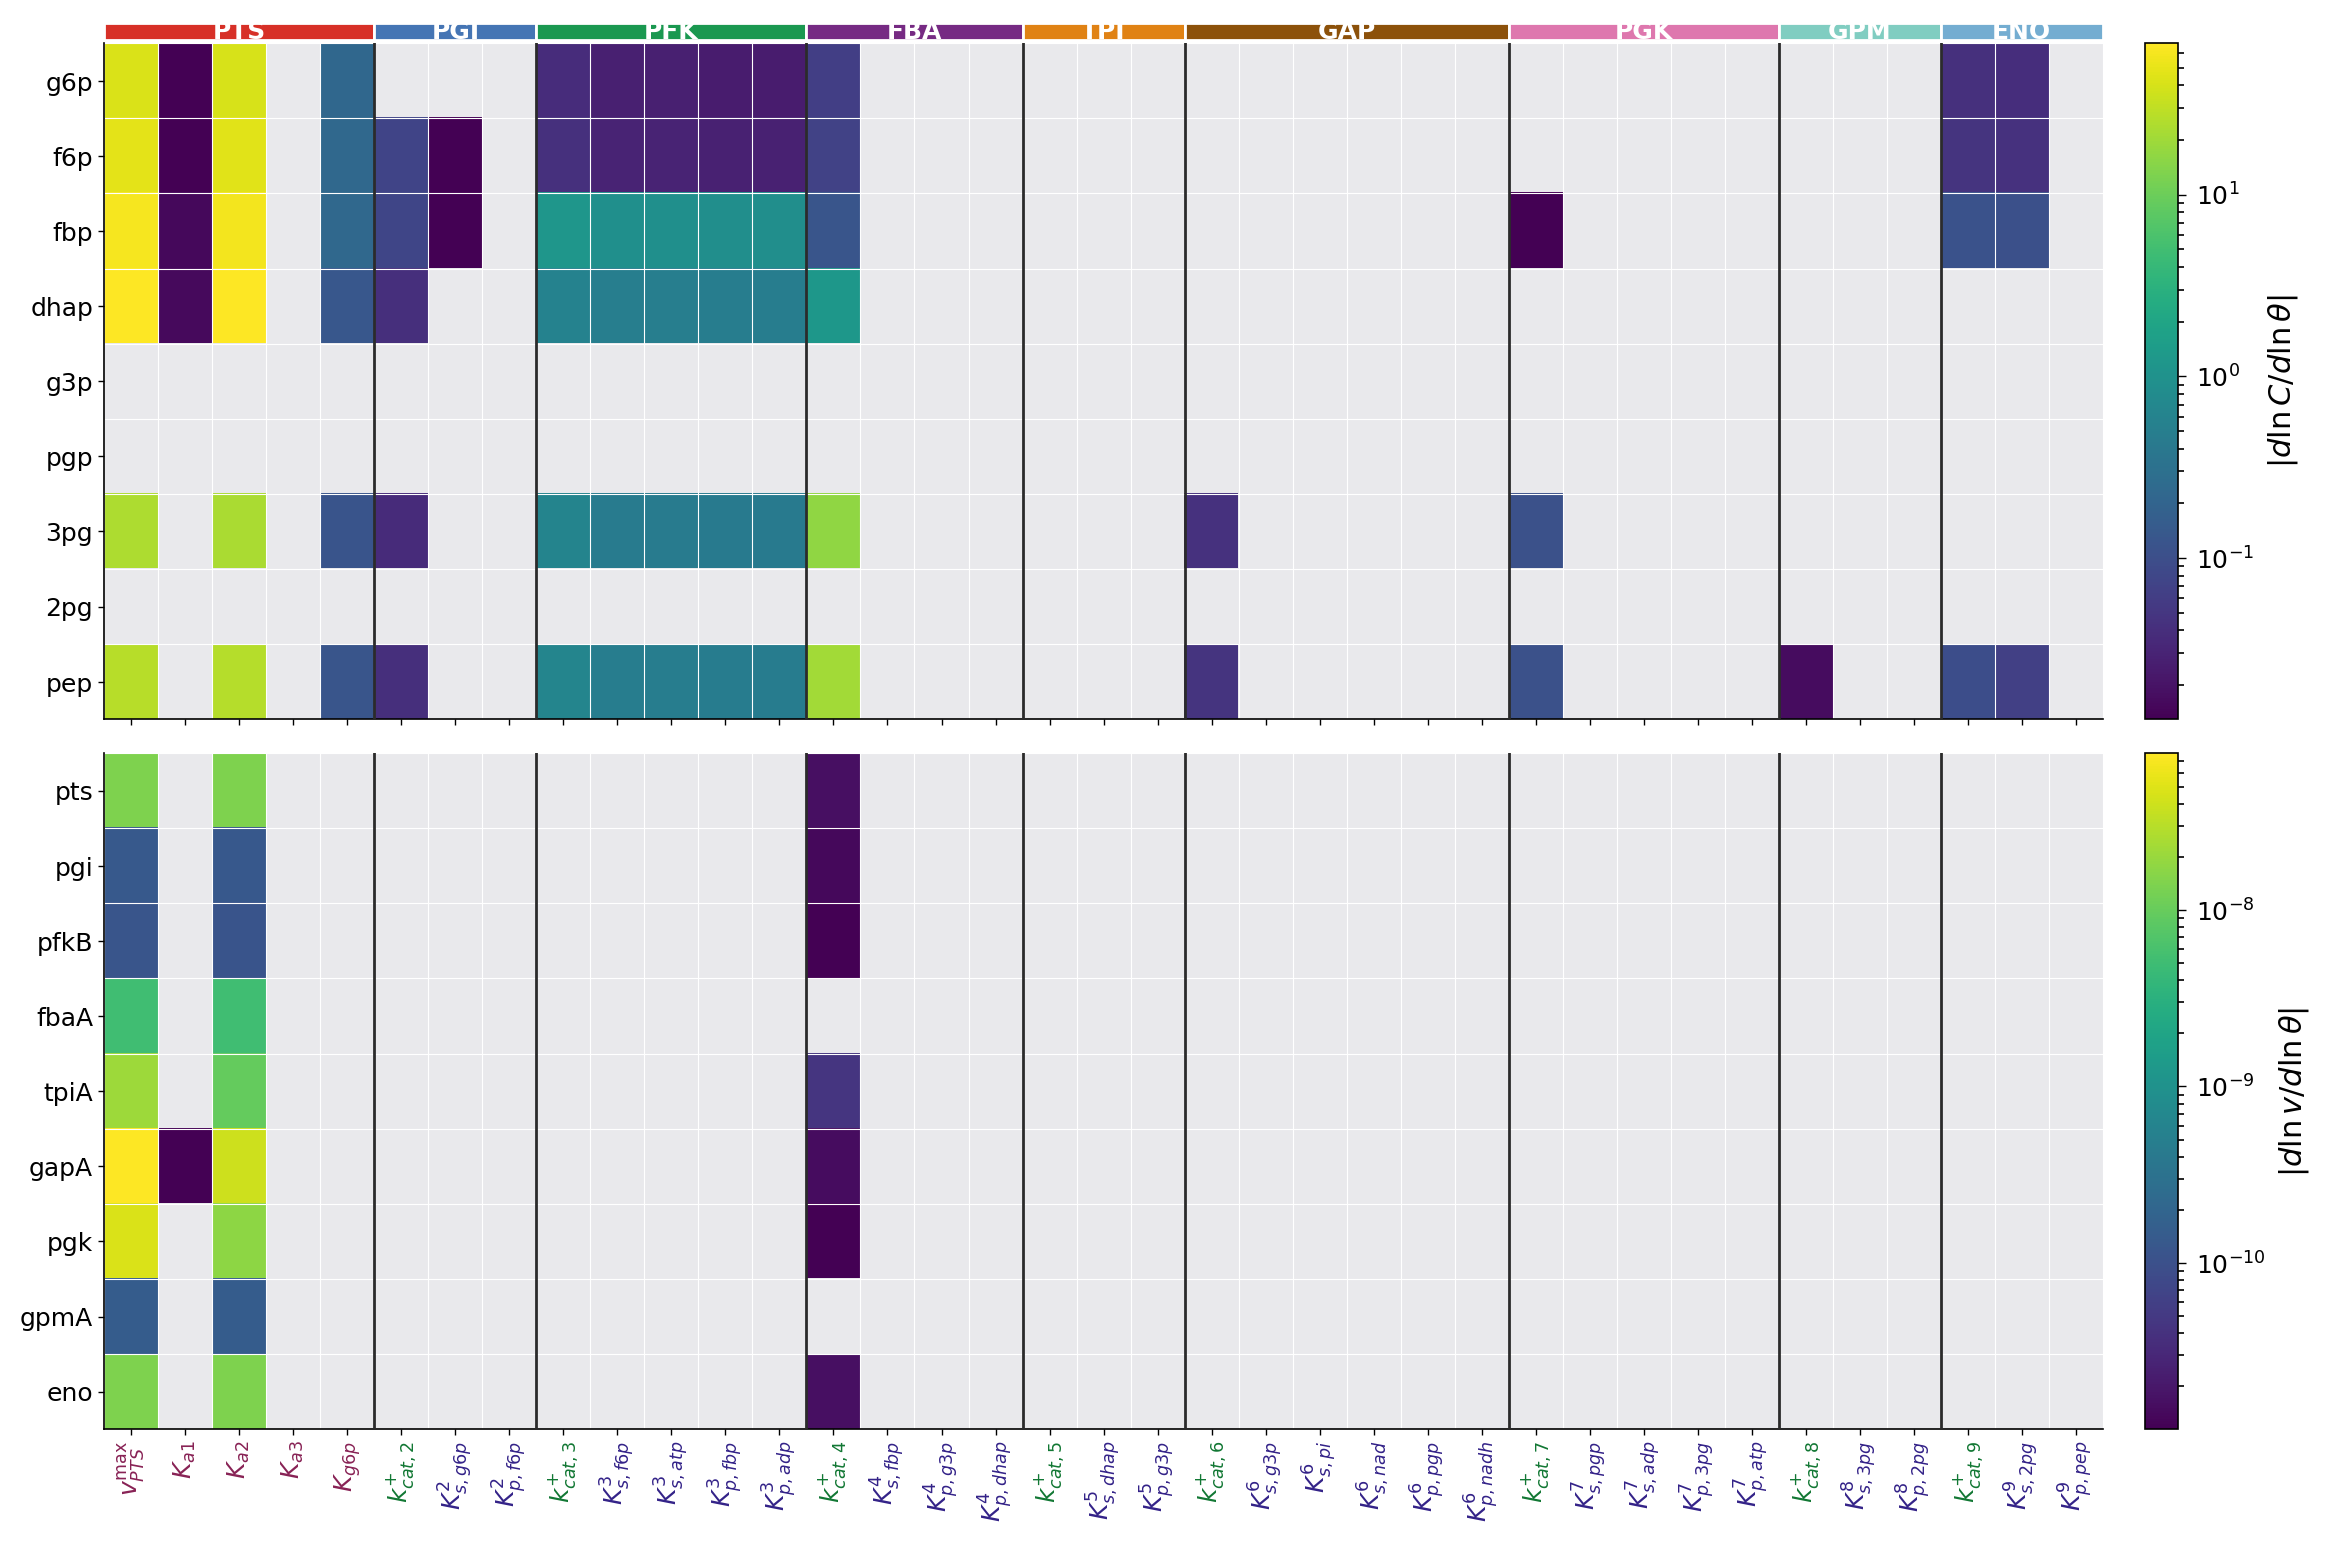

Saved: sensitivity_rel_mean.pdf
Thresholds: conc >= 0.01, flux >= 1e-11
Log scale: conc=True, flux=True
Cells shown: conc 79/333, flux 26/333


In [4]:
# Sensitivity heatmap: RELATIVE mean over conditions, split concentration/flux scales
import warnings
from matplotlib.colors import LogNorm

# all 22 conditions; some concentrations were never measured (no prediction) and
# so those rows stay blank/grey -- a limitation of the saved data, not a bug.
theta_fit = pd.read_csv(RESULTS_DIR / 'theta_fitted.csv', index_col=0)['value']
pred_fit = pd.read_csv(RESULTS_DIR / 'predictions_fitted.csv', index_col=0)

theta_vec = theta_fit.reindex(param_cols).to_numpy(dtype=float)            # (37,)
pred_aligned = pred_fit.reindex(index=cond_names, columns=row_name)        # (n_cond, 18)
Y = pred_aligned.to_numpy(dtype=float)
Y = np.where((Y > 0) & np.isfinite(Y), Y, np.nan)                          # guard div

rel_stack = G_stack * theta_vec[None, None, :] / Y[:, :, None]            # (n_cond, 18, 37)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)                        # all-NaN rows
    G_rel_mean = np.nanmean(np.abs(rel_stack), axis=0)                      # (18, 37)

# Threshold: cells whose mean |relative sensitivity| is below the threshold are
# masked (rendered grey).  
SENS_THRESH_CONC = 0.01     # keeps params that move a concentration by >~10%
SENS_THRESH_FLUX = 1e-11   # keeps the upper-quartile (most sensitive) flux cells

CONC_LOG_SCALE = True
FLUX_LOG_SCALE = True

G_plot = G_rel_mean[:, _perm]              

n_par = G_plot.shape[1]
conc_block = G_plot[:9, :]
flux_block  = G_plot[9:, :]

# Apply thresholds: values below the cut become NaN (drawn with set_bad grey)
conc_block = np.where(conc_block >= SENS_THRESH_CONC, conc_block, np.nan)
flux_block = np.where(flux_block >= SENS_THRESH_FLUX, flux_block, np.nan)

def _imshow_kw(block, use_log):
    """Build imshow color kwargs: LogNorm when use_log else linear 0..max.
    The log vmin is a robust 5th-percentile floor of positive cells so a few
    tiny values do not stretch the dynamic range."""
    pos = block[np.isfinite(block) & (block > 0)]
    if pos.size == 0:
        return dict(vmin=0, vmax=1.0)
    vmax = float(pos.max())
    if use_log:
        vmin = float(np.percentile(pos, 5))
        vmin = max(min(vmin, vmax / 10.0), vmax * 1e-9)
        return dict(norm=LogNorm(vmin=vmin, vmax=vmax))
    return dict(vmin=0, vmax=vmax)

# Row labels: strip 'C_' prefix for concentration, 'v_' prefix for flux
y_labels_conc = [nm.replace('C_', '') for nm in row_name[:9]]
y_labels_flux = [nm.replace('v_', '') for nm in row_name[9:]]

TOP_STRIP_Y = 1.004
TOP_STRIP_H = 0.026
STRIP_FS = 9

mpl.rcParams.update({
    'font.family':     'sans-serif',
    'font.size':        9,
    'axes.linewidth':   0.6,
    'mathtext.fontset': 'dejavusans',
})

fig = plt.figure(figsize=(13.5, 9.0), dpi=200)
gs = fig.add_gridspec(2, 1, height_ratios=[9, 9], hspace=0.05)
ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

cmap_seq = mpl.colormaps['viridis'].copy()
cmap_seq.set_bad('#e9e9ec')

im_top = ax_top.imshow(conc_block, aspect='auto', cmap=cmap_seq,
                        interpolation='none', **_imshow_kw(conc_block, CONC_LOG_SCALE))
im_bot = ax_bot.imshow(flux_block, aspect='auto', cmap=cmap_seq,
                        interpolation='none', **_imshow_kw(flux_block, FLUX_LOG_SCALE))

cbar_top = fig.colorbar(im_top, ax=ax_top, fraction=0.025, pad=0.02)
cbar_top.set_label(r'$|d\ln C / d\ln\theta|$', fontsize=11, labelpad=4)
cbar_top.ax.tick_params(labelsize=9, length=3, width=0.5)
cbar_top.outline.set_linewidth(0.6)

cbar_bot = fig.colorbar(im_bot, ax=ax_bot, fraction=0.025, pad=0.02)
cbar_bot.set_label(r'$|d\ln v / d\ln\theta|$', fontsize=11, labelpad=4)
cbar_bot.ax.tick_params(labelsize=9, length=3, width=0.5)
cbar_bot.outline.set_linewidth(0.6)

ax_top.set_yticks(range(9))
ax_top.set_yticklabels(y_labels_conc, fontsize=9)
ax_bot.set_yticks(range(9))
ax_bot.set_yticklabels(y_labels_flux, fontsize=9)

plt.setp(ax_top.get_xticklabels(), visible=False)
ax_bot.set_xticks(range(n_par))
ax_bot.set_xticklabels(param_labels_p, rotation=90, fontsize=9, ha='center')
for i, t in enumerate(ax_bot.get_xticklabels()):
    t.set_color(_type_color(i))
    t.set_fontweight('semibold')
ax_bot.tick_params(length=2, width=0.5, pad=2)
ax_top.tick_params(length=2, width=0.5, pad=2)

for ax, nrows in [(ax_top, 9), (ax_bot, 9)]:
    for k in np.arange(-0.5, n_par, 1):
        ax.plot([k, k], [-0.5, nrows - 0.5], color='white', lw=0.4, zorder=1)
    for k in np.arange(-0.5, nrows, 1):
        ax.plot([-0.5, n_par - 0.5], [k, k], color='white', lw=0.4, zorder=1)

for ax in [ax_top, ax_bot]:
    for _nm, i_s, i_e, _col in reaction_groups:
        if i_s != 0:
            ax.plot([i_s - 0.5, i_s - 0.5], [-0.5, 8.5], color='#2b2b2b', lw=1.0, zorder=3)

# Top reaction strip via blended_transform_factory over ax_top
trans_top = blended_transform_factory(ax_top.transData, ax_top.transAxes)
for name, i_s, i_e, col in reaction_groups:
    ax_top.add_patch(MplRect((i_s - 0.5, TOP_STRIP_Y), i_e - i_s + 1, TOP_STRIP_H,
                             transform=trans_top, facecolor=col, edgecolor='white',
                             lw=1.0, clip_on=False, zorder=4))
    ax_top.text((i_s + i_e) / 2, TOP_STRIP_Y + TOP_STRIP_H / 2, name,
                transform=trans_top, ha='center', va='center',
                fontsize=STRIP_FS, fontweight='bold', color='white',
                clip_on=False, zorder=5)

for s in ('top', 'right'):
    ax_top.spines[s].set_visible(False)
    ax_bot.spines[s].set_visible(False)

fig.savefig(FIG_DIR / 'sensitivity_rel_mean.pdf', dpi=300, bbox_inches='tight')
plt.show()

mpl.rcParams.update(mpl.rcParamsDefault)
n_shown_conc = int(np.isfinite(conc_block).sum())
n_shown_flux = int(np.isfinite(flux_block).sum())
print('Saved: sensitivity_rel_mean.pdf')
print(f'Thresholds: conc >= {SENS_THRESH_CONC}, flux >= {SENS_THRESH_FLUX}')
print(f'Log scale: conc={CONC_LOG_SCALE}, flux={FLUX_LOG_SCALE}')
print(f'Cells shown: conc {n_shown_conc}/{conc_block.size}, flux {n_shown_flux}/{flux_block.size}')

## Parameter Estimates with Confidence Intervals

Forest plot of fitted parameters $\hat{\theta}$ with 95% confidence intervals, ordered by reaction group (kcat first). Non-identifiable parameters are shown with grey open markers.

In [5]:
ci_df['ci_low']

v_max_1          76.908240
Ka1_1            -0.000337
Ka2_1             0.886445
Ka3_1            -0.090712
K_g6p_1          10.117408
Ks_g6p_pgi       -1.924593
Kp_f6p_pgi     -383.430763
kcat_f_2        -23.861043
Ks_f6p_3         -0.340430
Ks_atp_3         -0.360738
Kp_fbp_3         -0.380395
Kp_adp_3          0.011500
kcat_f_3        157.746561
Ks_fbp_4         -0.000034
Kp_g3p_4       -572.847757
Kp_dhap_4     -2818.249650
kcat_f_4          3.487317
kcat_f_5       4617.342821
Ks_dhap_5        -0.087870
Kp_g3p_5     -29239.430529
kcat_f_6        -80.124733
Ks_g3p_6       -148.451293
Ks_pi_6       -1889.526539
Ks_nad_6         -0.170400
Kp_pgp_6     -13682.772842
Kp_nadh_6     -8394.419823
kcat_f_7         41.248186
Ks_pgp_7         -0.023139
Ks_adp_7         -0.585601
Ks_3pg_7     -68761.060454
Ks_atp_7     -73864.572605
kcat_f_8        -74.254384
Ks_3pg_8         -0.036750
Ks_2pg_8     -56778.892931
kcat_f_9       -119.883219
Ks_2pg_9         -1.914054
Ks_pep_9       -195.022611
N

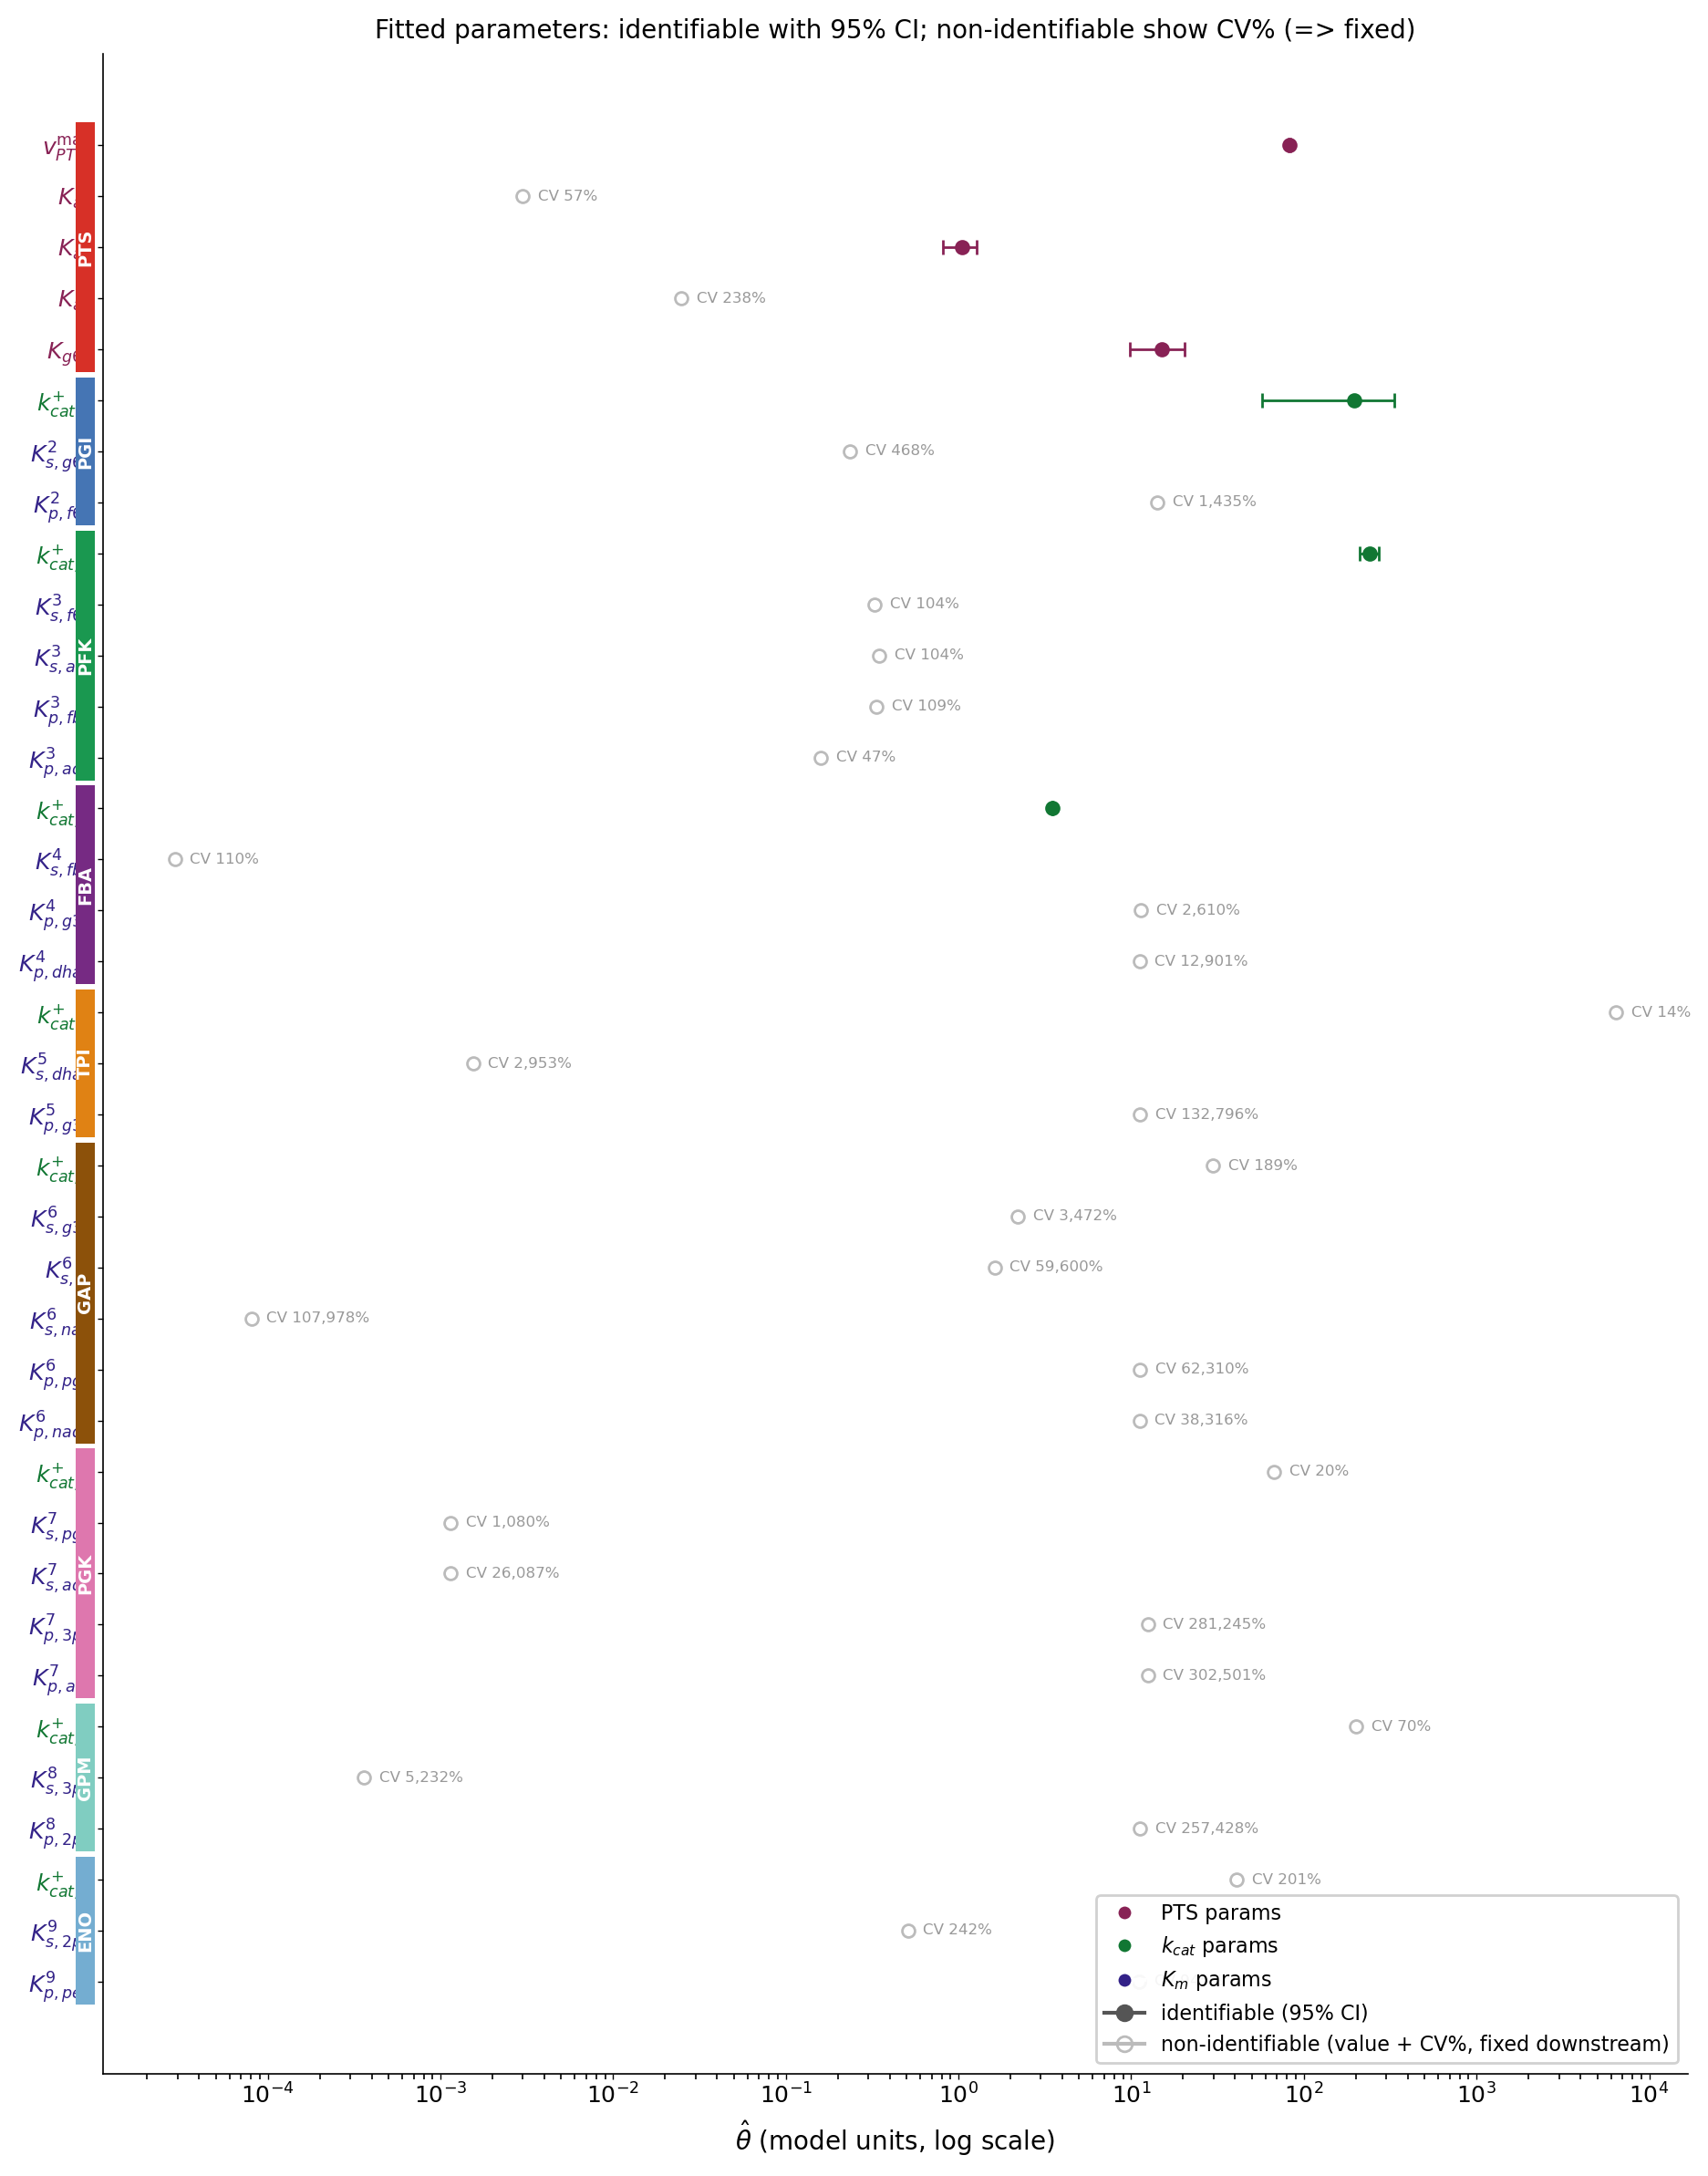

Saved: theta_ci_forest.pdf


In [6]:
# Forest plot of theta with confidence intervals.
#
# Identifiable params get a real 95% CI from the WELL-CONDITIONED identifiable-only
# covariance (plain log x-axis keeps v_max readable). The non-identifiable params
# are drawn as value-only grey markers AND annotated with their CV% from the FULL
# covariance -- those huge CV% (hundreds to thousands of percent) ARE the
# justification for fixing them in the downstream fix-and-reduce step.
from matplotlib.lines import Line2D

order = _perm
n = len(order)
y = np.arange(n)

ident_names = set(ci_ident_df.index)

mpl.rcParams.update({
    'font.family':     'sans-serif',
    'font.size':        9,
    'axes.linewidth':   0.6,
    'mathtext.fontset': 'dejavusans',
})

fig, ax = plt.subplots(figsize=(9.5, 12.0), dpi=200)

for i in range(n):
    pname = PARAMS[order[i]]
    fc = _type_color(i)
    if pname in ident_names:
        th = float(ci_ident_df.loc[pname, 'theta'])
        lo = float(ci_ident_df.loc[pname, 'ci_low'])
        hi = float(ci_ident_df.loc[pname, 'ci_high'])
        lo = max(lo, th * 1e-3)                       # keep whisker on log axis
        ax.errorbar(
            th, y[i], xerr=[[th - lo], [hi - th]],
            fmt='o', color=fc, markerfacecolor=fc,
            markersize=5, capsize=3, elinewidth=1.0, capthick=1.0, lw=1.0
        )
    else:
        th = float(ci_df.loc[pname, 'theta'])
        ax.plot(max(th, 1e-6), y[i], marker='o', color='#bbbbbb',
                markerfacecolor='none', markeredgecolor='#bbbbbb', markersize=5)
        # Annotate the huge CV% from the FULL covariance -> "why this is fixed".
        cv = float(ci_df.loc[pname, 'cv_percent'])
        if np.isfinite(cv):
            ax.annotate(f'CV {cv:,.0f}%', xy=(max(th, 1e-6), y[i]),
                        xytext=(6, 0), textcoords='offset points',
                        fontsize=6, color='#999999', va='center')

ax.set_xscale('log')
ax.set_xlabel(r'$\hat{\theta}$ (model units, log scale)', fontsize=10)

ax.set_yticks(y)
ax.set_yticklabels(param_labels_p, fontsize=9)
for i, t in enumerate(ax.get_yticklabels()):
    t.set_color(_type_color(i))
    t.set_fontweight('semibold')
ax.invert_yaxis()
ax.tick_params(length=2, width=0.5, pad=2)

# Left-side reaction-group color strip via MplRect with blended transform
STRIP_W  = 0.012
GAP_LEFT = 0.005
trans_left = blended_transform_factory(ax.transAxes, ax.transData)
for name, i_s, i_e, col in reaction_groups:
    pos_in_plot = [p for p, orig in enumerate(_perm) if i_s <= orig <= i_e]
    if not pos_in_plot:
        continue
    y0 = min(pos_in_plot) - 0.45
    y1 = max(pos_in_plot) + 0.45
    ax.add_patch(MplRect(
        (-(STRIP_W + GAP_LEFT), y0), STRIP_W, y1 - y0,
        transform=trans_left, facecolor=col, edgecolor='none',
        clip_on=False, zorder=4
    ))
    ax.text(-(GAP_LEFT + STRIP_W / 2), (y0 + y1) / 2, name,
            transform=trans_left, ha='center', va='center',
            fontsize=7, fontweight='bold', color='white',
            rotation=90, clip_on=False, zorder=5)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=TYPE_COLOR['pts'],
           markersize=6, label='PTS params'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=TYPE_COLOR['kcat'],
           markersize=6, label=r'$k_{cat}$ params'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=TYPE_COLOR['km'],
           markersize=6, label=r'$K_m$ params'),
    Line2D([0], [0], marker='o', color='#555555', markerfacecolor='#555555',
           markersize=6, label='identifiable (95% CI)'),
    Line2D([0], [0], marker='o', color='#bbbbbb', markerfacecolor='none',
           markeredgecolor='#bbbbbb', markersize=6,
           label='non-identifiable (value + CV%, fixed downstream)'),
]
ax.legend(handles=legend_elements, fontsize=8, loc='lower right',
          framealpha=0.9, edgecolor='#cccccc')

ax.set_title('Fitted parameters: identifiable with 95% CI; non-identifiable show CV% (=> fixed)',
             fontsize=10)

for s in ('top', 'right'):
    ax.spines[s].set_visible(False)

fig.tight_layout()
fig.savefig(FIG_DIR / 'theta_ci_forest.pdf', dpi=300, bbox_inches='tight')
plt.show()

mpl.rcParams.update(mpl.rcParamsDefault)
print('Saved: theta_ci_forest.pdf')

## Correlation Matrix

Parameter correlation matrix $r_{ij}$: full (unmasked) and masked ($|r| \geq 0.9$ only).

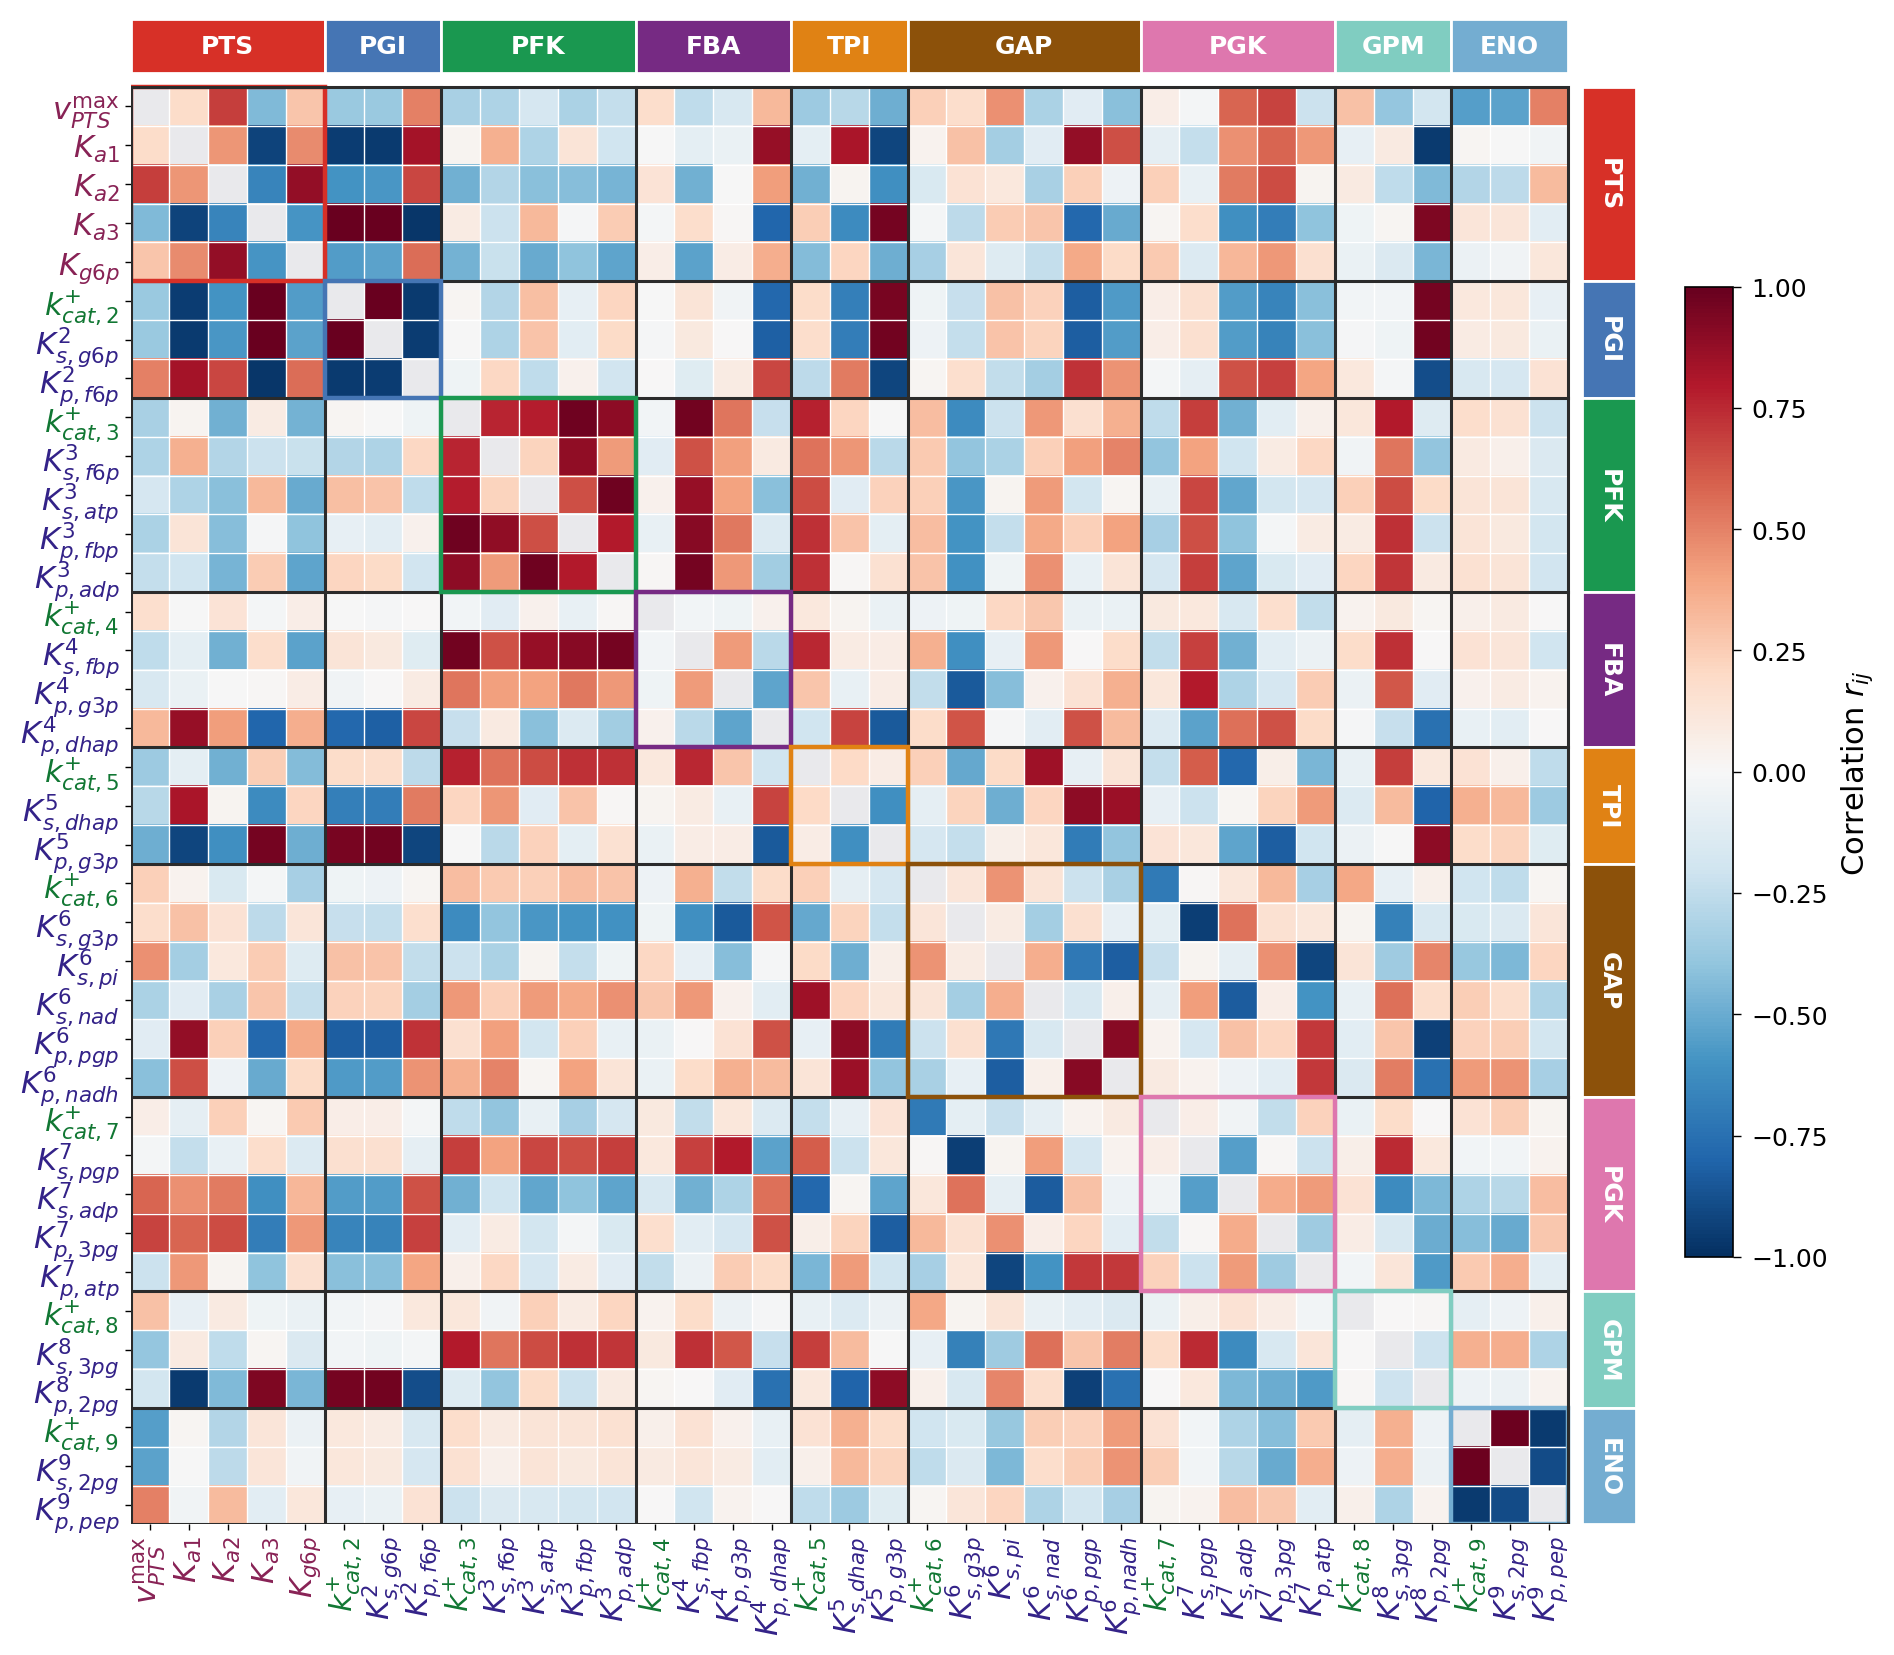

Saved: corr_not_masked.pdf


In [7]:
# Correlation heatmap, unmasked (diagonal -> NaN)
corr_p = corr_df.values[np.ix_(_perm, _perm)].copy().astype(float)
np.fill_diagonal(corr_p, np.nan)

styled_matrix_heatmap(
    corr_p, -1, 1,
    r'Correlation $r_{ij}$',
    FIG_DIR / 'corr_not_masked.pdf'
)
print('Saved: corr_not_masked.pdf')

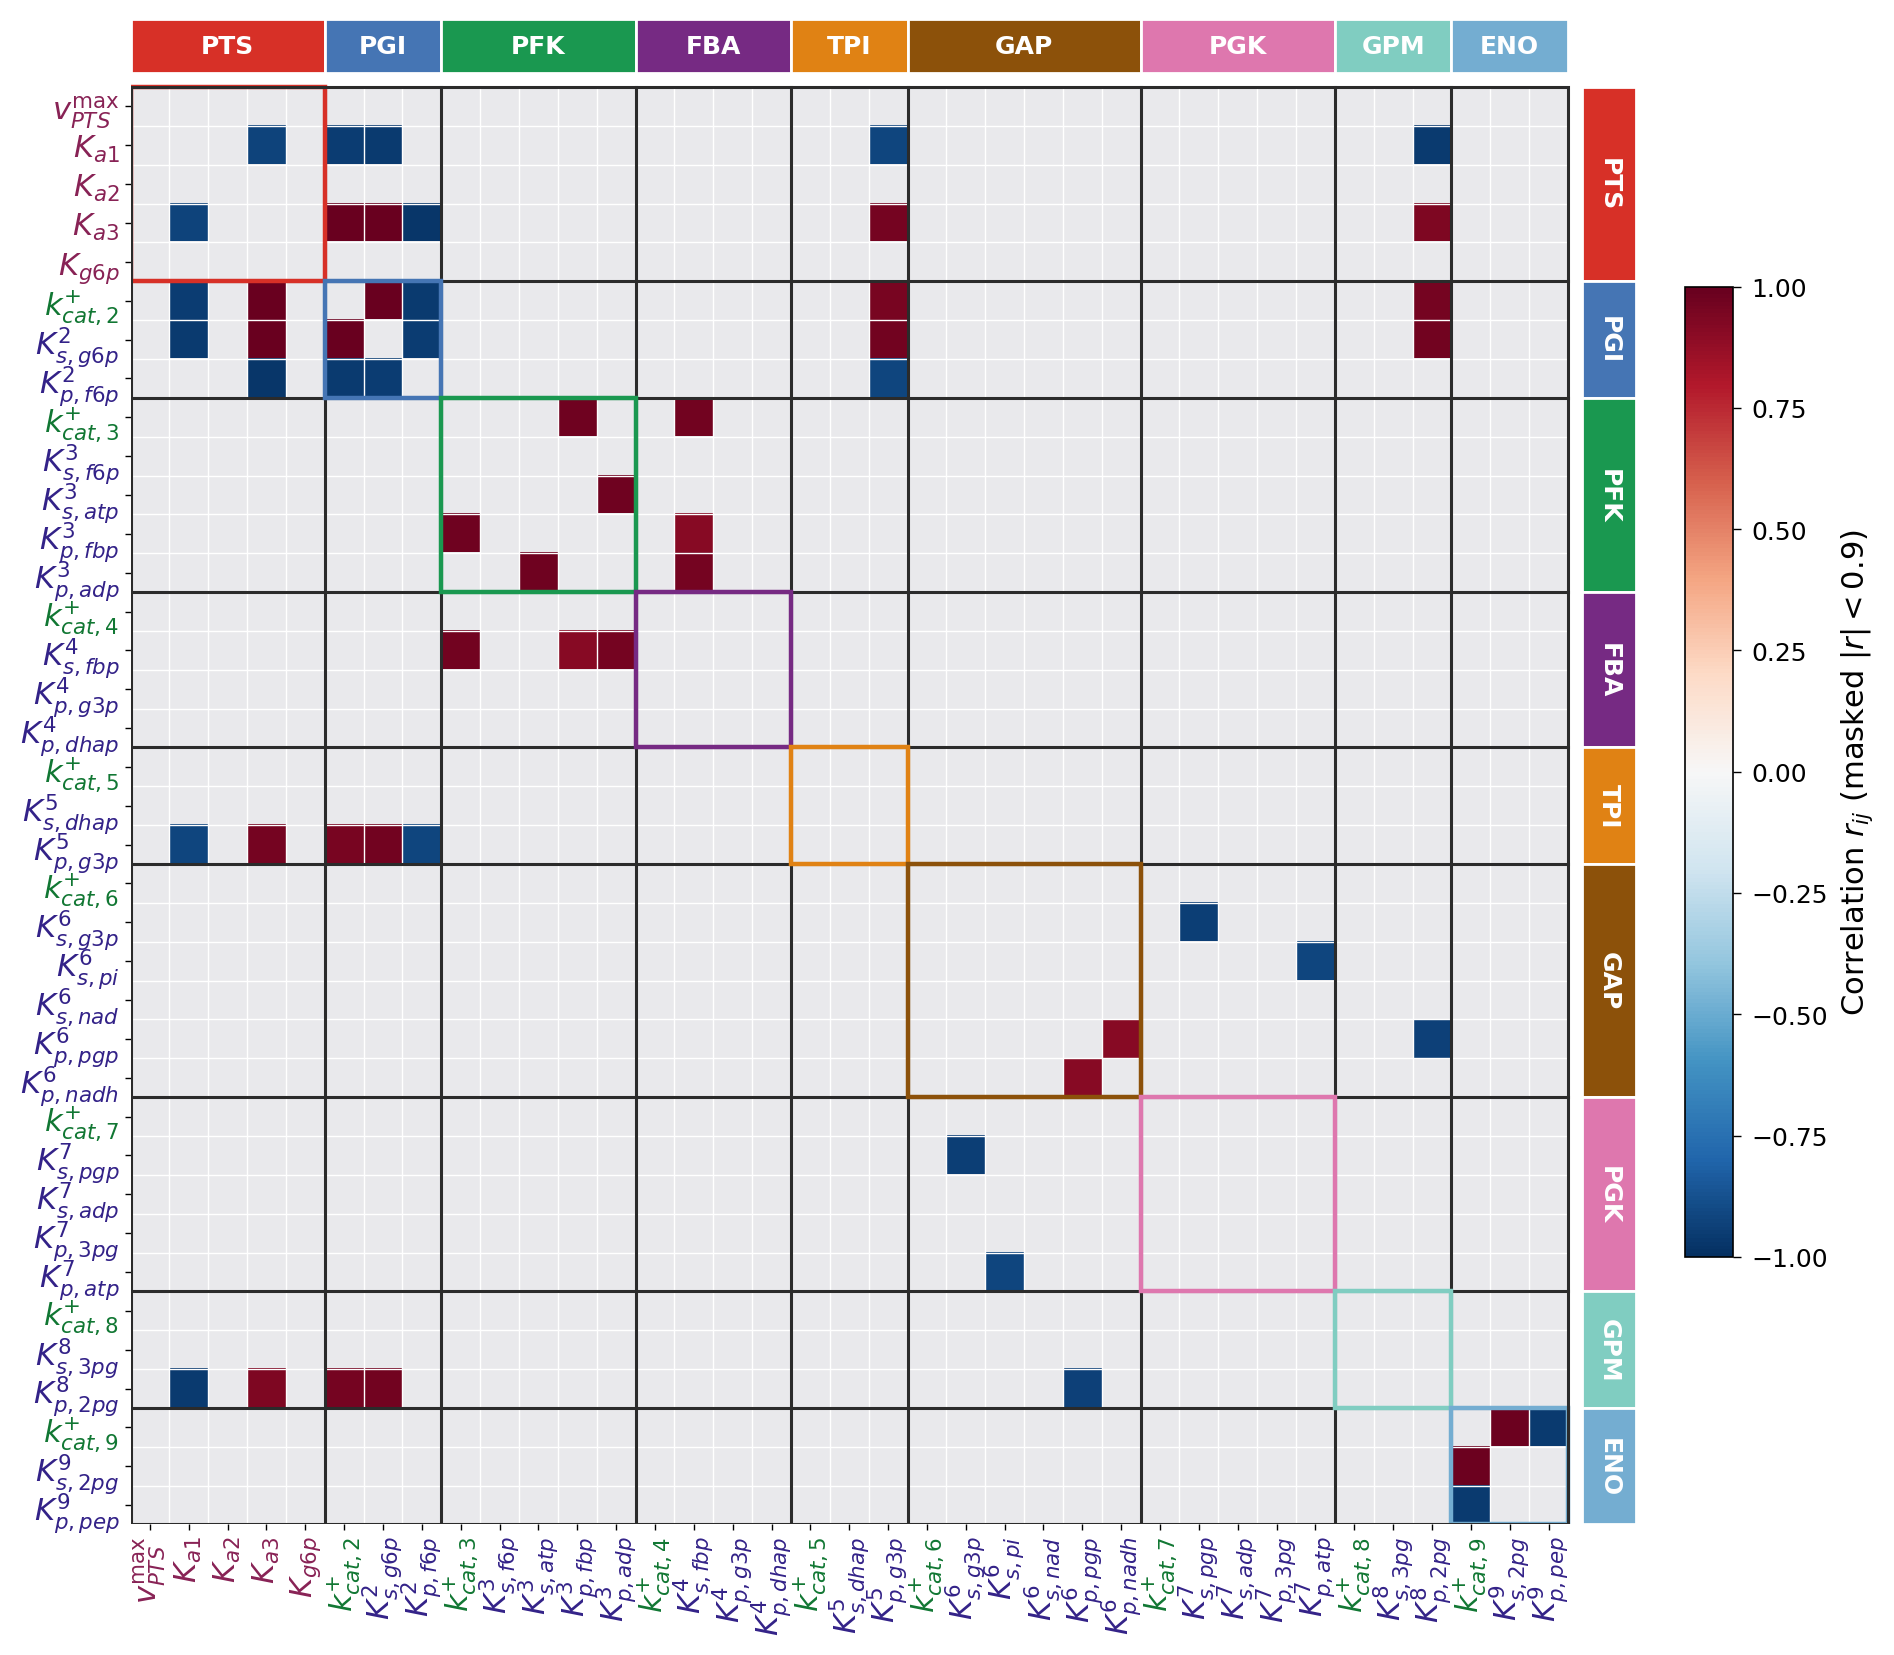

Saved: corr_masked.pdf


In [8]:
# Correlation heatmap, masked: show only |r| >= 0.9 (diagonal -> NaN)
corr_p_full = corr_df.values[np.ix_(_perm, _perm)].copy().astype(float)
corr_masked = np.where(np.abs(corr_p_full) >= 0.90, corr_p_full, np.nan)
np.fill_diagonal(corr_masked, np.nan)

styled_matrix_heatmap(
    corr_masked, -1, 1,
    r'Correlation $r_{ij}$ (masked $|r|<0.9$)',
    FIG_DIR / 'corr_masked.pdf'
)
print('Saved: corr_masked.pdf')

# Confidence intervals across parameters ($\hat{\theta}\pm2\sigma$)

Per-parameter confidence intervals with parameters on the x-axis. A CI that
crosses zero means the data leave the parameter's sign undetermined -> it is
fixed downstream. Because the raw magnitudes span many orders, the first plot is
**normalized by $\hat{\theta}$** (every estimate at 1.0, half-width $2\sigma/|\hat{\theta}|$);
the second shows the **raw** intervals on a symlog axis.

In [9]:
cov_df

,v_max_1,Ka1_1,Ka2_1,Ka3_1,K_g6p_1,Ks_g6p_pgi,Kp_f6p_pgi,kcat_f_2,Ks_f6p_3,Ks_atp_3,...,Ks_pgp_7,Ks_adp_7,Ks_3pg_7,Ks_atp_7,kcat_f_8,Ks_3pg_8,Ks_2pg_8,kcat_f_9,Ks_2pg_9,Ks_pep_9
v_max_1,12.877768,1.100236e-03,0.260802,-9.402133e-02,1.639705,-1.452693,3.650817e+02,-1.124502e+02,-0.373917,-0.218388,...,-7.980317e-04,0.625663,8.494189e+04,-2.880080e+04,148.831495,-2.615428e-02,-1.931118e+04,-1.615973e+02,-2.360792,189.755475
Ka1_1,0.001101,2.900897e-06,0.000079,-9.298146e-05,0.001302,-0.001804,2.874887e-01,-1.375867e-01,0.000206,-0.000188,...,-4.946679e-06,0.000234,3.456021e+01,2.795856e+01,-0.019888,2.774198e-06,-4.729378e+01,2.251867e-03,-0.000005,-0.006715
Ka2_1,0.260814,7.925778e-05,0.011132,-4.122118e-03,0.150929,-0.068117,1.433670e+01,-5.338307e+00,-0.010594,-0.016003,...,-9.819685e-05,0.016440,2.422491e+03,1.031376e+02,1.326773,-5.051039e-04,-1.352413e+03,-2.532392e+00,-0.034219,3.517700
Ka3_1,-0.094039,-9.297974e-05,-0.004122,3.471680e-03,-0.056756,0.064304,-1.163713e+01,4.959608e+00,-0.004272,0.006840,...,1.304145e-04,-0.010756,-1.433438e+03,-8.875364e+02,-0.352710,2.288020e-05,1.599862e+03,5.742131e-01,0.009026,-0.636209
K_g6p_1,1.639953,1.301923e-03,0.150932,-5.675513e-02,2.652574,-0.960369,1.845945e+02,-7.745691e+01,-0.122762,-0.297068,...,-2.784871e-03,0.163263,2.498701e+04,9.861909e+03,-14.563514,-4.455809e-03,-2.157673e+04,-7.970048e+00,-0.064128,19.783114
Ks_g6p_pgi,-1.453018,-1.803591e-03,-0.068123,6.430384e-02,-0.960390,1.214723,-2.122507e+02,9.313828e+01,-0.116708,0.114208,...,2.154649e-03,-0.185112,-2.595834e+04,-1.729733e+04,-2.247097,-9.399444e-04,3.070206e+04,7.666303e+00,0.130122,-7.282354
Kp_f6p_pgi,365.141253,2.874821e-01,14.337657,-1.163711e+01,184.597160,-212.249093,4.114483e+04,-1.647197e+04,14.367481,-18.557023,...,-2.284624e-01,38.464117,4.861920e+06,3.039792e+06,3029.785260,-7.235954e-02,-5.219176e+06,-2.725825e+03,-41.789592,3129.269576
kcat_f_2,-112.475512,-1.375851e-01,-5.338745,4.959642e+00,-77.458659,93.138414,-1.647212e+04,7.257711e+03,-8.437314,9.281784,...,1.677661e-01,-14.271762,-1.983164e+06,-1.346742e+06,-343.043527,-4.284713e-02,2.357410e+06,7.214383e+02,11.772803,-738.884617
Ks_f6p_3,-0.373878,2.059371e-04,-0.010593,-4.273023e-03,-0.122751,-0.116720,1.436981e+01,-8.438207e+00,0.116213,0.027176,...,1.710630e-03,-0.020408,9.967764e+02,2.627162e+03,-1.843021,3.462689e-03,-3.907618e+03,2.533857e+00,0.020086,-5.202128
Ks_atp_3,-0.218426,-1.875234e-04,-0.016004,6.839868e-03,-0.297069,0.114205,-1.855674e+01,9.281567e+00,0.027177,0.130238,...,2.995095e-03,-0.056495,-2.309411e+03,-2.266049e+03,12.172265,4.475579e-03,2.031569e+03,3.928495e+00,0.056811,-5.987111


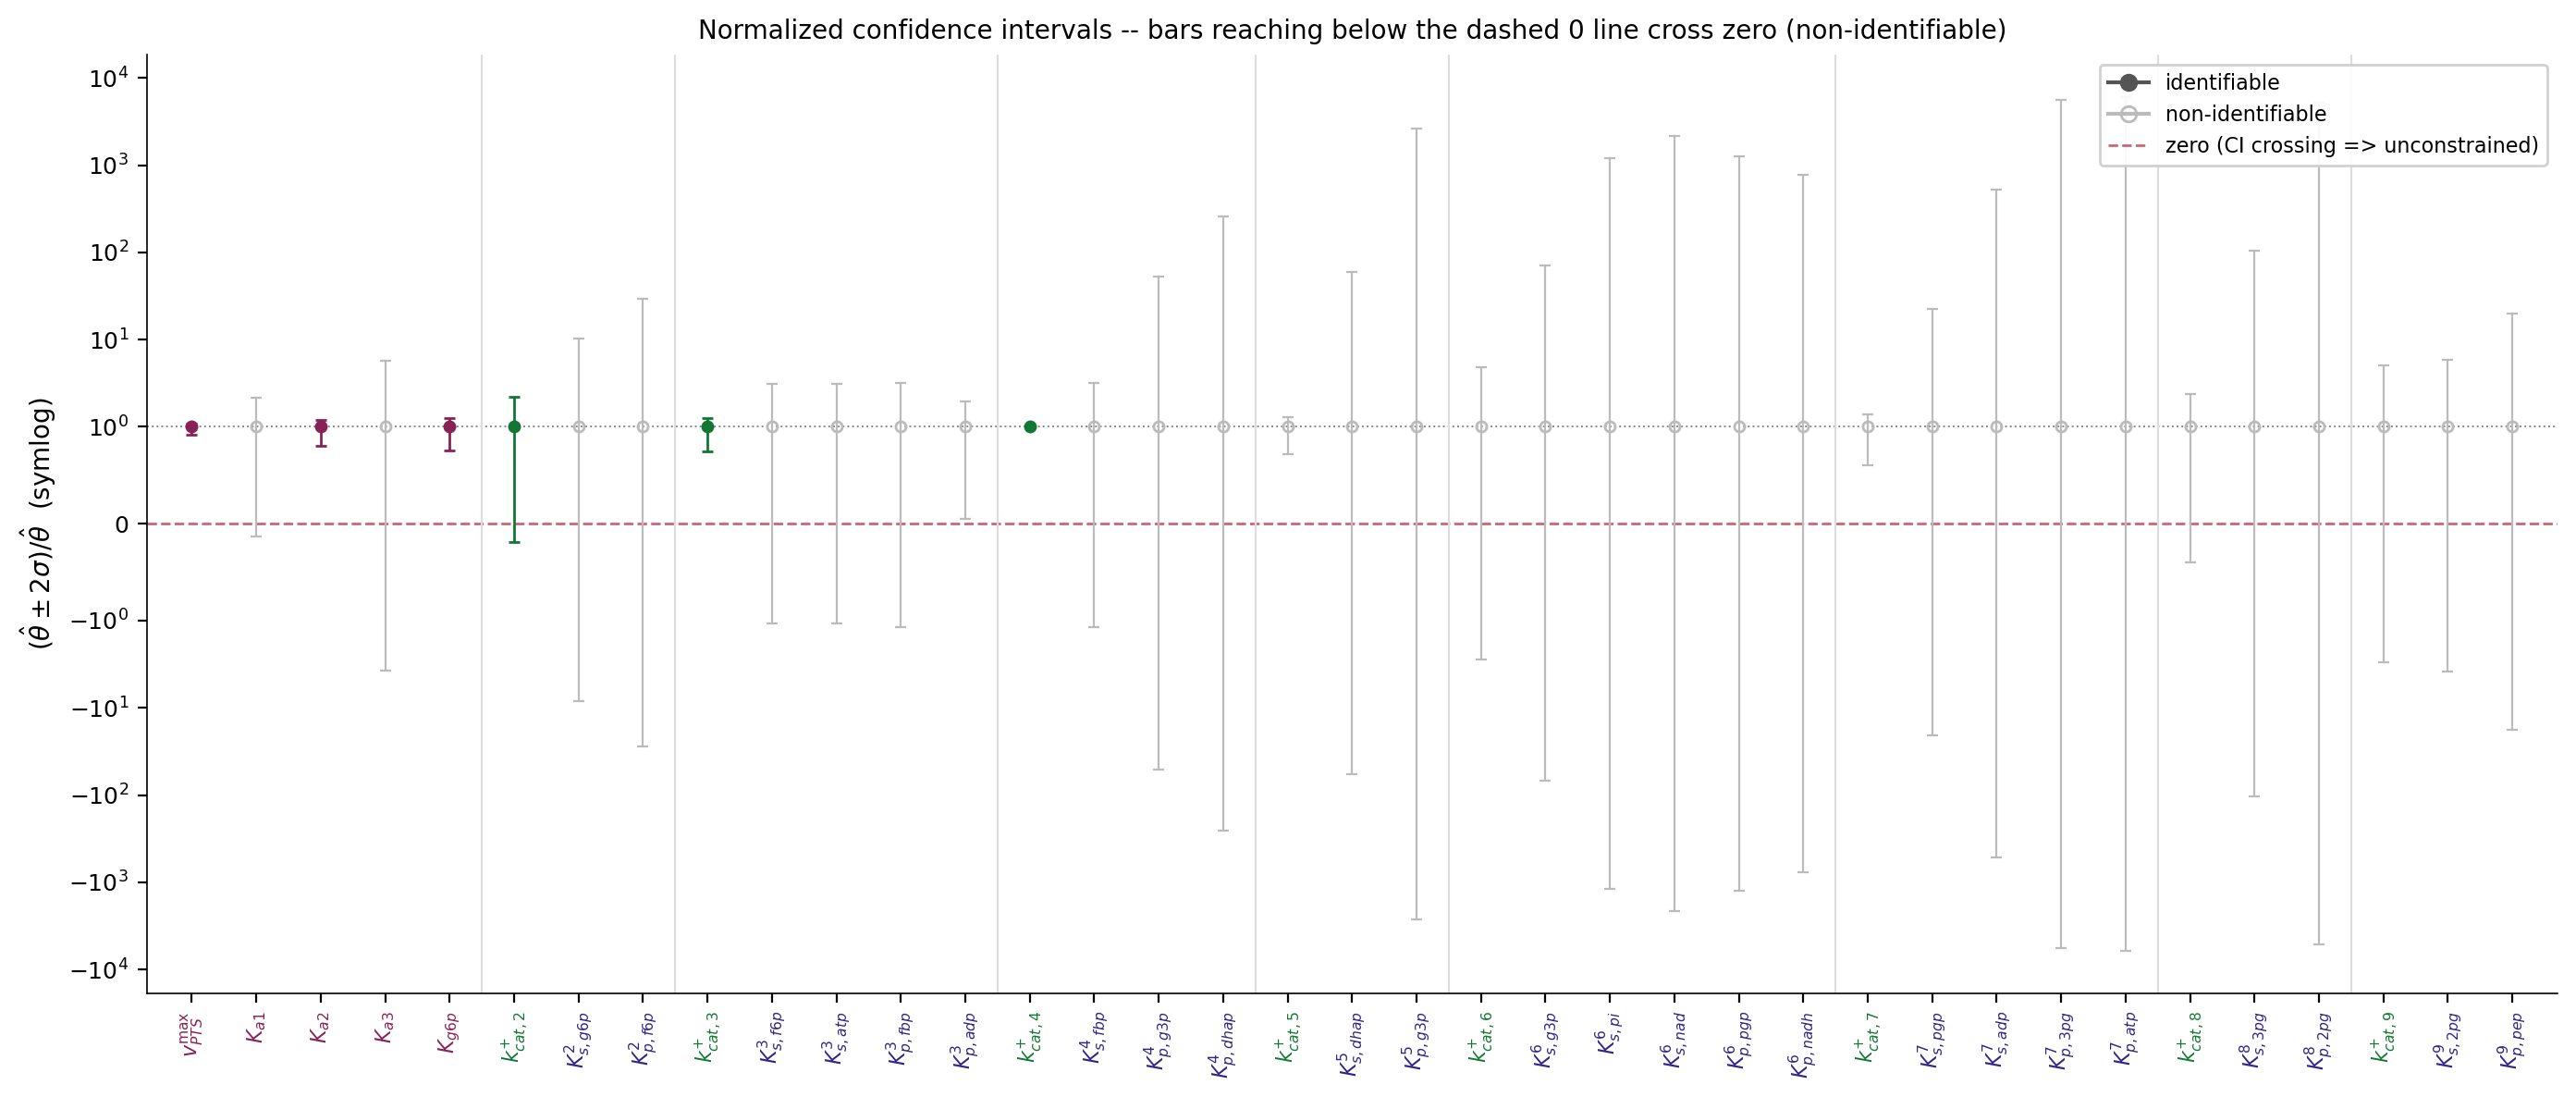

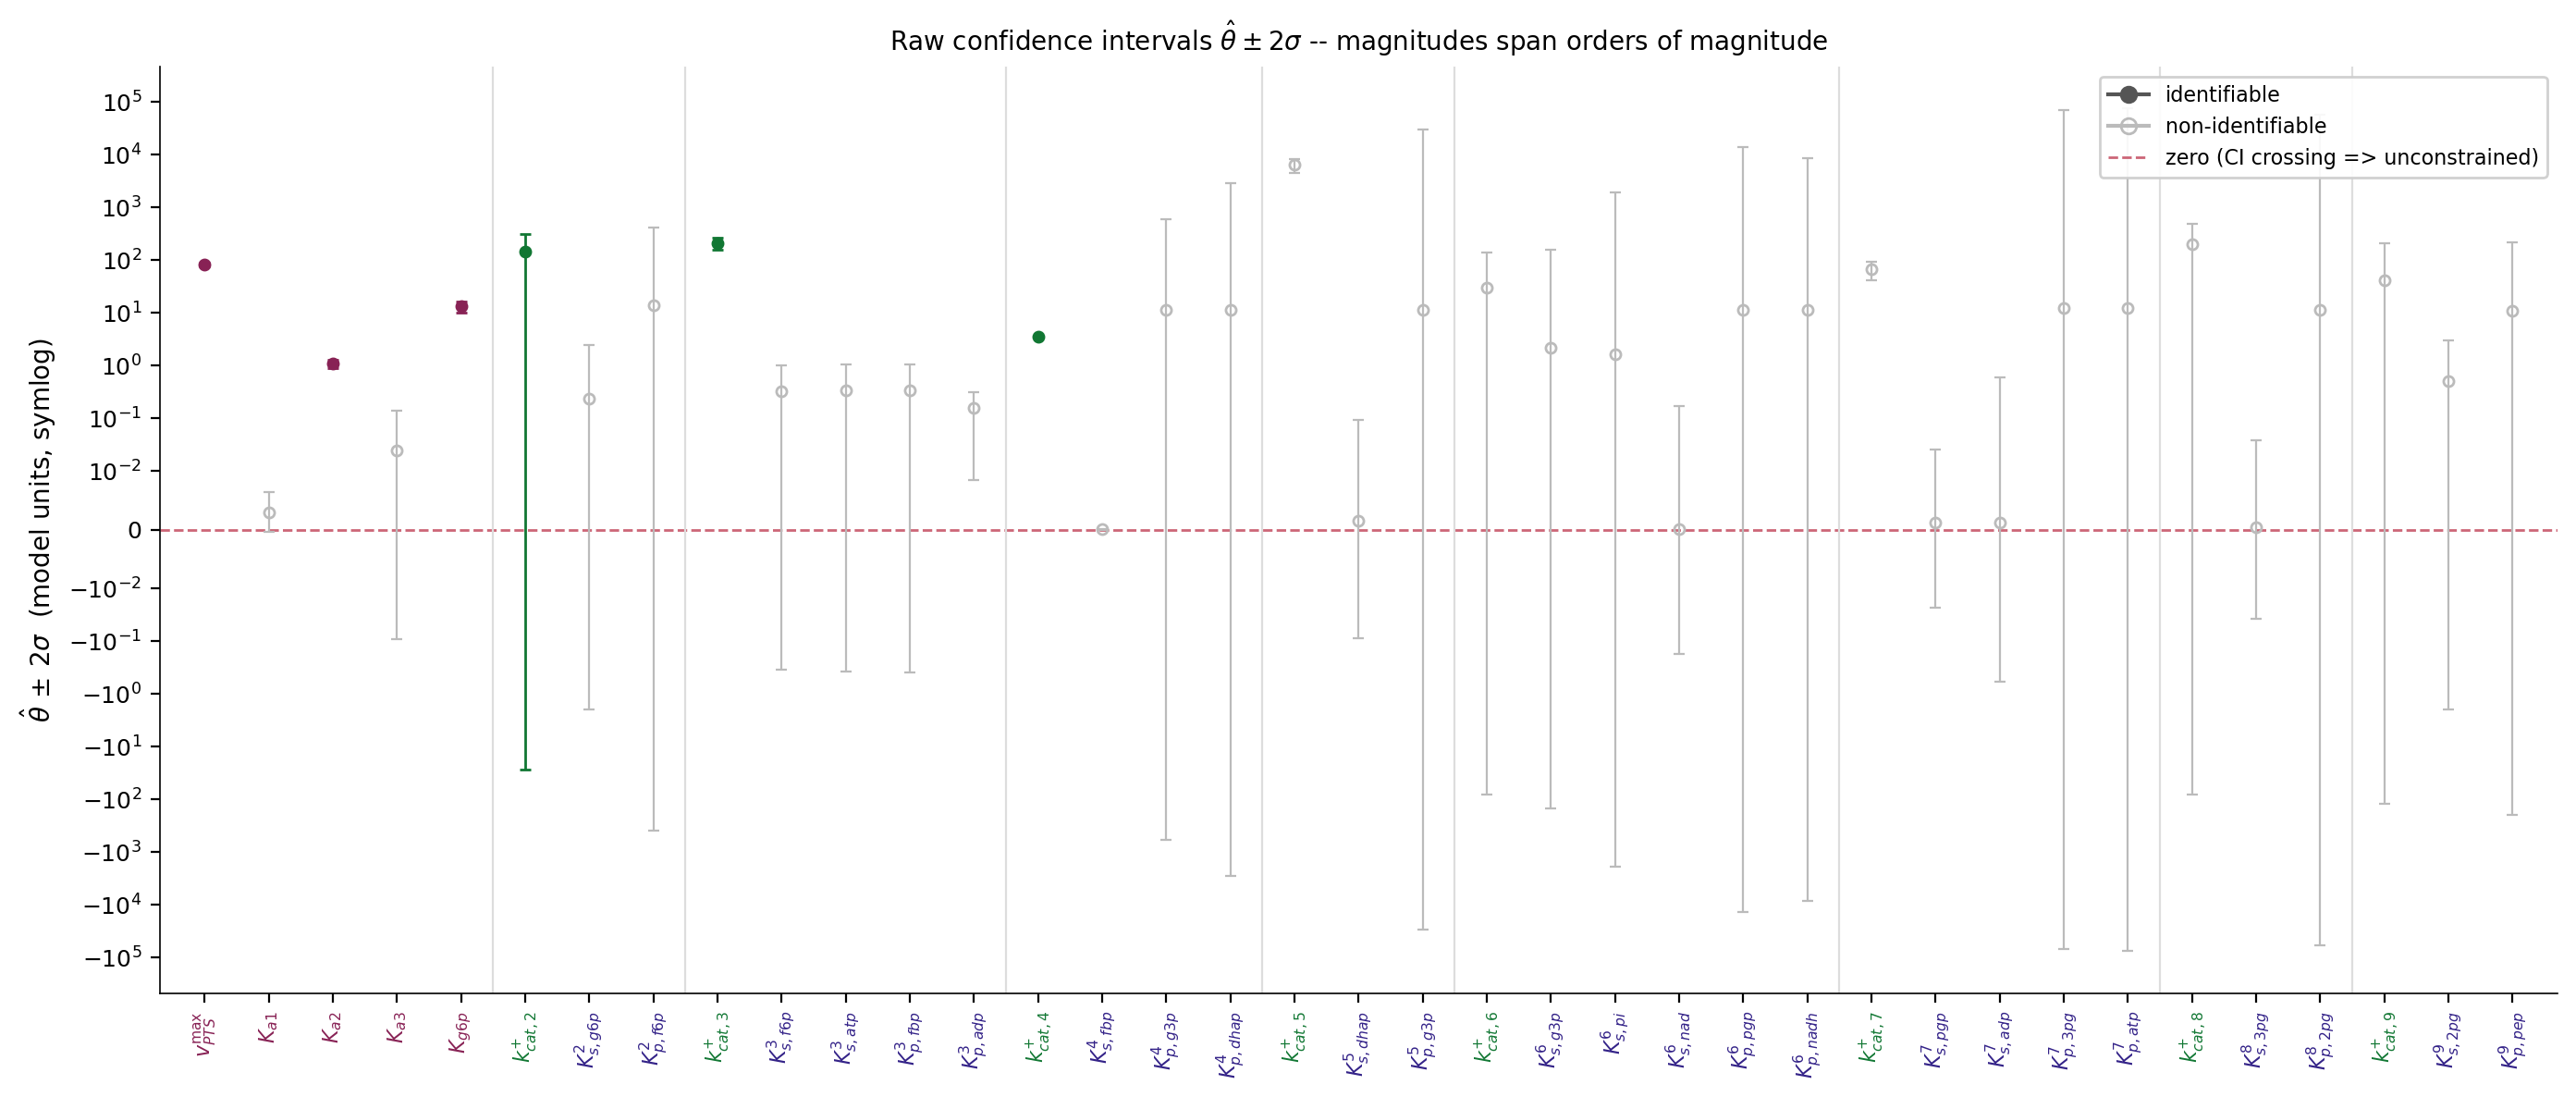

Saved: theta_ci_normalized.pdf, theta_ci_raw.pdf
29/37 parameters have a (theta +/- 2 sigma) CI that crosses zero.


In [10]:
# Confidence-interval plots: theta +/- 2*sigma per parameter, params on the x-axis.
#
# A parameter whose CI crosses zero is not constrained by the data (sign unknown)
# -> it is fixed downstream.  Two views:
#   (1) NORMALIZED by theta  -> every estimate sits at 1.0, half-width = 2*sigma/|theta|;
#       a bar reaching below the y=0 line means the CI crosses zero.  This is the
#       readable view because raw magnitudes span many orders.
#   (2) RAW (model units) on a symlog y-axis -> same information, true magnitudes.
from matplotlib.lines import Line2D

order = _perm
labels = param_labels_p                                  # already in _perm order
theta = ci_df['theta'].iloc[order].to_numpy(dtype=float)
sd = ci_df['std_err'].iloc[order].to_numpy(dtype=float)
names_ord = [PARAMS[i] for i in order]
ident_mask = np.array([nm in set(ci_ident_df.index) for nm in names_ord])
x = np.arange(len(order))
K_SIGMA = 2.0                                            # CI = theta +/- 2 sigma

def _draw_ci(center, half, ylabel, title, fname, linthresh, draw_one_line):
    mpl.rcParams.update({
        'font.family': 'sans-serif', 'font.size': 9,
        'axes.linewidth': 0.6, 'mathtext.fontset': 'dejavusans',
    })
    fig, ax = plt.subplots(figsize=(14.0, 6.0), dpi=200)
    for i in range(len(x)):
        if ident_mask[i]:
            ax.errorbar(x[i], center[i], yerr=half[i], fmt='o', color=_type_color(i),
                        markerfacecolor=_type_color(i), markersize=4,
                        capsize=2, elinewidth=1.0, capthick=1.0)
        else:
            ax.errorbar(x[i], center[i], yerr=half[i], fmt='o', color='#bbbbbb',
                        markerfacecolor='none', markeredgecolor='#bbbbbb',
                        markersize=4, capsize=2, elinewidth=0.8, capthick=0.8)
    ax.set_yscale('symlog', linthresh=linthresh)
    ax.axhline(0, color='#cc6677', lw=1.0, ls='--', zorder=0)
    if draw_one_line:
        ax.axhline(1, color='#888888', lw=0.7, ls=':', zorder=0)
    # reaction-group separators (first plotted position of each group)
    starts = sorted({min(p for p, orig in enumerate(_perm) if i_s <= orig <= i_e)
                     for _nm, i_s, i_e, _c in reaction_groups})
    for p in starts:
        if p > 0:
            ax.axvline(p - 0.5, color='#dddddd', lw=0.8, zorder=0)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=90, fontsize=8)
    for i, t in enumerate(ax.get_xticklabels()):
        t.set_color(_type_color(i)); t.set_fontweight('semibold')
    ax.set_xlim(-0.7, len(x) - 0.3)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=10)
    leg = [
        Line2D([0], [0], marker='o', color='#555555', markerfacecolor='#555555',
               markersize=6, label='identifiable'),
        Line2D([0], [0], marker='o', color='#bbbbbb', markerfacecolor='none',
               markeredgecolor='#bbbbbb', markersize=6, label='non-identifiable'),
        Line2D([0], [0], color='#cc6677', lw=1.0, ls='--',
               label='zero (CI crossing => unconstrained)'),
    ]
    ax.legend(handles=leg, fontsize=8, loc='upper right', framealpha=0.9, edgecolor='#cccccc')
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    fig.tight_layout()
    fig.savefig(FIG_DIR / fname, dpi=300, bbox_inches='tight')
    plt.show()
    mpl.rcParams.update(mpl.rcParamsDefault)

# (1) Normalized by theta: estimate at 1.0, half-width = 2*sigma/|theta|.
_draw_ci(
    np.ones_like(theta), K_SIGMA * sd / np.abs(theta),
    r'$(\hat{\theta}\pm2\sigma)/\hat{\theta}$  (symlog)',
    r'Normalized confidence intervals -- bars reaching below the dashed 0 line cross zero (non-identifiable)',
    'theta_ci_normalized.pdf', linthresh=1.0, draw_one_line=True,
)

# (2) Raw (model units), symlog y so the order-of-magnitude spread is visible.
_draw_ci(
    theta, K_SIGMA * sd,
    r'$\hat{\theta}\,\pm\,2\sigma$  (model units, symlog)',
    r'Raw confidence intervals $\hat{\theta}\pm2\sigma$ -- magnitudes span orders of magnitude',
    'theta_ci_raw.pdf', linthresh=1e-2, draw_one_line=False,
)

n_cross = int(((theta - K_SIGMA * sd) <= 0).sum())
print('Saved: theta_ci_normalized.pdf, theta_ci_raw.pdf')
print(f'{n_cross}/{len(x)} parameters have a (theta +/- 2 sigma) CI that crosses zero.')

# report

In [11]:
# Correlated-pairs LaTeX table: pairs with |r| >= 0.9
# Reconstruct param_latex from the ORIGINAL ALL_PARAMS order (= list(corr_df.columns))
all_params_orig = list(corr_df.columns)
param_latex = {k: _param_labels_orig[j] for j, k in enumerate(all_params_orig)}

pairs = []
n_params = len(all_params_orig)
corr_vals = corr_df.values

for i in range(n_params):
    for j in range(i + 1, n_params):
        r = corr_vals[i, j]
        if np.isfinite(r) and abs(r) >= 0.9:
            pairs.append({
                'param_i': param_latex[all_params_orig[i]],
                'param_j': param_latex[all_params_orig[j]],
                'r': round(r, 4)
            })

pairs_df = pd.DataFrame(pairs, columns=['param_i', 'param_j', 'r'])
pairs_df = pairs_df.sort_values('r', key=abs, ascending=False).reset_index(drop=True)

print(f'Number of correlated pairs (|r| >= 0.9) over all 37 params: {len(pairs_df)}')
print(pairs_df.to_latex(index=False))

# Context: the structural report's n_corr_pairs_ge_0.9 is NOT directly comparable.
# It counts strongly-correlated pairs only AMONG IDENTIFIABLE parameters, and it
# uses the relative-FIM pseudo-inverse correlation (sentitivity.py), not the saved
# correlation.csv used here. So a difference is expected, not a bug. For an
# apples-to-apples reference we also report the count restricted to identifiable
# params using THIS (saved) correlation matrix.
ident_params = list(struct_df.index[struct_df['identifiable'] == True])
n_ident_pairs_saved = 0
for i in range(len(ident_params)):
    for j in range(i + 1, len(ident_params)):
        r = corr_df.loc[ident_params[i], ident_params[j]]
        if np.isfinite(r) and abs(r) >= 0.9:
            n_ident_pairs_saved += 1

n_corr_report = int(ident_df['n_corr_pairs_ge_0.9'].iloc[0])
print(f'\nStructural report n_corr_pairs_ge_0.9 = {n_corr_report} '
      '(identifiable-only, relative-FIM correlation).')
print(f'Saved correlation.csv, identifiable-only: {n_ident_pairs_saved} pair(s).')
print(f'Saved correlation.csv, all params: {len(pairs_df)} pairs.')
print('These count different things, so they are not expected to be equal.')


Number of correlated pairs (|r| >= 0.9) over all 37 params: 29
\begin{tabular}{llr}
\toprule
param_i & param_j & r \\
\midrule
$K_{s,g6p}^{2}$ & $k^{+}_{cat,2}$ & 0.991900 \\
$K_{a3}$ & $K_{s,g6p}^{2}$ & 0.990200 \\
$K_{a3}$ & $k^{+}_{cat,2}$ & 0.988000 \\
$k^{+}_{cat,9}$ & $K_{s,2pg}^{9}$ & 0.981000 \\
$K_{s,atp}^{3}$ & $K_{p,adp}^{3}$ & 0.974600 \\
$K_{a3}$ & $K_{p,f6p}^{2}$ & -0.973700 \\
$K_{p,fbp}^{3}$ & $k^{+}_{cat,3}$ & 0.970400 \\
$k^{+}_{cat,3}$ & $K_{s,fbp}^{4}$ & 0.964900 \\
$K_{s,g6p}^{2}$ & $K_{p,g3p}^{5}$ & 0.963300 \\
$K_{s,g6p}^{2}$ & $K_{p,2pg}^{8}$ & 0.961400 \\
$K_{a1}$ & $K_{s,g6p}^{2}$ & -0.960800 \\
$K_{a3}$ & $K_{p,g3p}^{5}$ & 0.959900 \\
$k^{+}_{cat,9}$ & $K_{p,pep}^{9}$ & -0.959700 \\
$K_{a1}$ & $K_{p,2pg}^{8}$ & -0.958300 \\
$k^{+}_{cat,2}$ & $K_{p,2pg}^{8}$ & 0.955000 \\
$K_{p,adp}^{3}$ & $K_{s,fbp}^{4}$ & 0.953700 \\
$K_{p,f6p}^{2}$ & $k^{+}_{cat,2}$ & -0.953200 \\
$k^{+}_{cat,2}$ & $K_{p,g3p}^{5}$ & 0.953100 \\
$K_{s,g6p}^{2}$ & $K_{p,f6p}^{2}$ & -0.949400 

In [12]:
# Fix-justification table: the FULL covariance (with its huge ranges) is the
# evidence for WHY the non-identifiable params are fixed downstream.  For each
# non-identifiable param (flagged by the structural FIM-rank criterion) we report
# the value it is fixed AT (theta), its std_err, variance, CV%, and whether its
# 95% CI crosses zero -- all read from the FULL covariance.  A CI that crosses
# zero or a CV% >> 100% means the data do not constrain the parameter, so it is
# held at its literature / prior value in the fix-and-reduce step.
ident_set = set(ci_ident_df.index)
non_ident = [p for p in PARAMS if p not in ident_set]

fix_tbl = ci_df.loc[non_ident, ['theta', 'std_err', 'ci_low', 'ci_high', 'cv_percent']].copy()
fix_tbl['variance'] = np.diag(cov_df.loc[non_ident, non_ident].to_numpy())
fix_tbl['ci_crosses_zero'] = (fix_tbl['ci_low'] <= 0) & (fix_tbl['ci_high'] >= 0)
fix_tbl = fix_tbl.sort_values('cv_percent', ascending=False)
fix_tbl.index.name = 'param_fixed'

out = RESULTS_DIR / 'fix_justification.csv'
fix_tbl.to_csv(out)
n_cross = int(fix_tbl['ci_crosses_zero'].sum())
print(f'Saved: {out}  ({len(fix_tbl)} parameters fixed downstream)')
print(f'Primary criterion: structural non-identifiability (FIM rank '
      f'{int(ident_df["FIM_rank"].iloc[0])} of 37).')
print(f'Corroborated by the full covariance: CV% range '
      f'{fix_tbl["cv_percent"].min():.0f}% .. {fix_tbl["cv_percent"].max():,.0f}%; '
      f'{n_cross}/{len(fix_tbl)} have a 95% CI that crosses zero.')
print()
print(fix_tbl.round(3).to_string())

Saved: results/first_estimation/fix_justification.csv  (31 parameters fixed downstream)
Primary criterion: structural non-identifiability (FIM rank 4 of 37).
Corroborated by the full covariance: CV% range 14% .. 302,501%; 28/31 have a 95% CI that crosses zero.

                theta    std_err     ci_low    ci_high  cv_percent      variance  ci_crosses_zero
param_fixed                                                                                      
Ks_atp_7       12.460  37692.364 -73864.573  73889.493  302500.579  1.420714e+09             True
Ks_3pg_7       12.476  35088.539 -68761.060  68786.013  281244.682  1.231206e+09             True
Ks_2pg_8       11.255  28974.565 -56778.893  56801.404  257427.841  8.395254e+08             True
Kp_g3p_5       11.238  14923.811 -29239.431  29261.907  132796.322  2.227201e+08             True
Ks_nad_6        0.000      0.087     -0.170      0.171  107978.474  8.000000e-03             True
Kp_pgp_6       11.213   6986.727 -13682.773  13705.1